# Jakobshavn Glacier NDSI Change Detection Using Landsat

This notebook uses Landsat imagery and Google Earth Engine to compare summer snow/ice conditions over Jakobshavn Glacier between 2000 and 2024, based on changes in the Normalised Difference Snow Index (NDSI).

The full project overview is provided in the README file.

## Project workflow

1. Define a study area around Jakobshavn Glacier.
2. Load Landsat 7, 8, and 9 surface reflectance imagery.
3. Filter for summer imagery by date and >= 85% AOI coverage.
4. Create median summer composites for 2000 and 2024.
5. Calculate NDSI for both years.
6. Calculate ΔNDSI to map relative snow/ice change.

## 1) Imports and Functions

In [1]:
# Imports
import ee
import geemap
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import matplotlib.colors as mcolors
import matplotlib.colorbar as mcolorbar
%matplotlib inline

In [2]:
# Creating a directory to store downloaded files
directory = Path("data")
directory.mkdir(parents = True, exist_ok = True)
print("Data directory:", directory.resolve())

Data directory: /content/data


In [3]:
# Function 1: Auth GEE
def auth_gee(project_id: str, use_highvolume: bool = True) -> None:
    """
    Authenticate and initialize Google Earth Engine using a specified project ID

    Input:
    - project_id: Google Earth Engine project ID
    - use_highvolume: If True, use the Earth Engine high-volume API endpoint
    """
    ee.Authenticate()
    if use_highvolume:
        ee.Initialize(project=project_id,
                     opt_url='https://earthengine-highvolume.googleapis.com')
    else:
        ee.Initialize(project=project_id)

In [4]:
# Function 2: Calculating AOI coverage of an image
def add_aoi_cov(img):
  """
  Calculating AOI coverage of an image

  Input:
  - img: Landsat image

  Output:
  - img: Landsat image % AOi coverage
  """

  fp = img.geometry()  # robust footprint
  inter = fp.intersection(AOI, 1000)  # 1 km margin
  cov = inter.area(1000).divide(aoi_area)
  return img.set('aoi_cov', cov)

In [5]:
# Function 3 and 4: Preprocessing landsat data
def prep_l7(img):
  """
  Preprocess Landsat 7 images by selecting bands, scaling, and clipping to the AOI

  Input:
  - img: Landsat 7 image

  Output:
  - img: Preprocessed Landsat 7 image
  """
  return (img
        .select(['SR_B2', 'SR_B5'], ['green', 'swir1'])
        .multiply(0.0000275).add(-0.2)
        .clip(AOI))

def prep_l89(img):
  """
    Preprocess Landsat 8/9 images by selecting bands, scaling, and clipping to the AOI

  Input:
  - img: Landsat 8/9 image

  Output:
  - img: Preprocessed Landsat 8/9 image
  """
  return (img
        .select(['SR_B3', 'SR_B6'], ['green', 'swir1'])
        .multiply(0.0000275).add(-0.2)
        .clip(AOI))

In [6]:
# Function 5: Calculating NDSI and only keeping pixels with >= X NDSI
def ndsi_calc_mask(img, ndsi_threshold):
  """
  Calculate NDSI over an image and filter for pixels with only >= X NDSI

  Input:
  - img: Landsat image
  - ndsi_threshold: Minimum NDSI value

  Output:
  - img: Landsat image with NDSI values and mask
  """

  ndsi = img.normalizedDifference(['green', 'swir1']).rename('NDSI')
  return img.addBands(ndsi).updateMask(ndsi.gte(ndsi_threshold))

In [7]:
# Function 6: Converting EE image into np array for plotting
def ee_band_to_array(image, band, scale=100):
    """
    Convert one Earth Engine image band into a 2D NumPy array.

    Input:
    - image: The EE image
    - band: The band of interest in the EE image
    - scale: Sampling scale

    Output:
    - array: 2D NumPy array
    """
    array = geemap.ee_to_numpy(
        image.select(band),
        region=AOI,
        scale=scale
    )

    array = np.squeeze(array)
    array = np.ma.masked_invalid(array)

    return array

## 2) Data Analyis

In [8]:
auth_gee(project_id="YOUR-PROJECT-ID") # Change the project ID to yours

In [9]:
# Importing the satellite imagery IC and AOI FC
  # Using multiple landsat data because l7 does not have data over AOI from 2020 onwards
l7 = ee.ImageCollection('LANDSAT/LE07/C02/T1_L2')
l8 = ee.ImageCollection('LANDSAT/LC08/C02/T1_L2')
l9 = ee.ImageCollection('LANDSAT/LC09/C02/T1_L2')

  # Filtering based on the AOI, AOI coverage, and dates
    # [min_lon, min_lat, max_lon, max_lat]
AOI = ee.Geometry.Rectangle([-52.01295, 68.59101, -48.98705, 69.66899])
extent = [-52.01295, -48.98705, 68.59101, 69.66899]
start_date = '2000-07-15' # Peak summer in Greenland -> July
end_date = '2024-07-15'

  # Defining AOI coverage function
aoi_area = AOI.area(1000)  # 1 km error margin
cov_thresh = 0.85 # Only select images with AOI coverage >= 85%

In [10]:
# 2000 candidates (Landsat 7)
cand_2000 = (l7
    .filterBounds(AOI)
    .filterDate('2000-06-01', '2000-08-31') # Summer in greenland: June - Aug
    .map(add_aoi_cov)
    .filter(ee.Filter.gte('aoi_cov', cov_thresh)))

# 2024 candidates (Landsat 8/9)
cand_2024 = (l8.merge(l9)
    .filterBounds(AOI)
    .filterDate('2024-06-01', '2024-08-31')
    .map(add_aoi_cov)
    .filter(ee.Filter.gte('aoi_cov', cov_thresh)))

print('2000 candidates after cov filter:', cand_2000.size().getInfo())
print('2024 candidates after cov filter:', cand_2024.size().getInfo())

2000 candidates after cov filter: 2
2024 candidates after cov filter: 8


In [11]:
# Traditional GEE cloud mask confuses snow with clouds, resulting in images with very few pixels left
  # To avoid this, changing clouds are partially addressed by finding median composites for all images in each summer
    # Additionally, only pixels with NDSI over a certain threshold is used as snow/ice have higher NDSI than clouds
cand_2000_comp = cand_2000.map(prep_l7)
comp_2000 = cand_2000_comp.median()

cand_2024_comp = cand_2024.map(prep_l89)
comp_2024 = cand_2024_comp.median()

# Keeping only pixels with NDSI > 0.3
comp_2000_snow = ndsi_calc_mask(comp_2000, ndsi_threshold=0.3)
comp_2024_snow = ndsi_calc_mask(comp_2024, ndsi_threshold=0.3)

ndsi_change = (comp_2024_snow.select("NDSI").subtract(comp_2000_snow.select("NDSI")).rename("dNDSI"))

## 3) Results

In [12]:
# Interactive map
Map = geemap.Map()
Map.centerObject(AOI, 8)

# low NDSI to high NDSI: red = snow loss, grey = approx same amount of snow, blue = snow gain
ndsi_vis = {'min': 0.0, 'max': 1.0, 'palette': ['brown', 'purple', 'red', 'blue', 'cyan']}
dndsi_vis = {'min': -0.5, 'max': 0.5, 'palette': ['red', 'white', 'blue']}

Map.addLayer(comp_2000_snow.select('NDSI'), ndsi_vis, '2000 NDSI (median)')
Map.addLayer(comp_2024_snow.select('NDSI'), ndsi_vis, '2024 NDSI (median)')
Map.addLayer(ndsi_change, dndsi_vis, 'ΔNDSI (2024 − 2000)')
Map.addLayer(AOI, {}, 'AOI', False)
Map

Map(center=[69.13221635493673, -50.50000000000004], controls=(WidgetControl(options=['position', 'transparent_…

In [13]:
# Converting the EE NDSI images into np arrays:
ndsi_2000_arr = ee_band_to_array(comp_2000_snow, "NDSI")
ndsi_2024_arr = ee_band_to_array(comp_2024_snow, "NDSI")
dndsi_arr = ee_band_to_array(ndsi_change, "dNDSI")

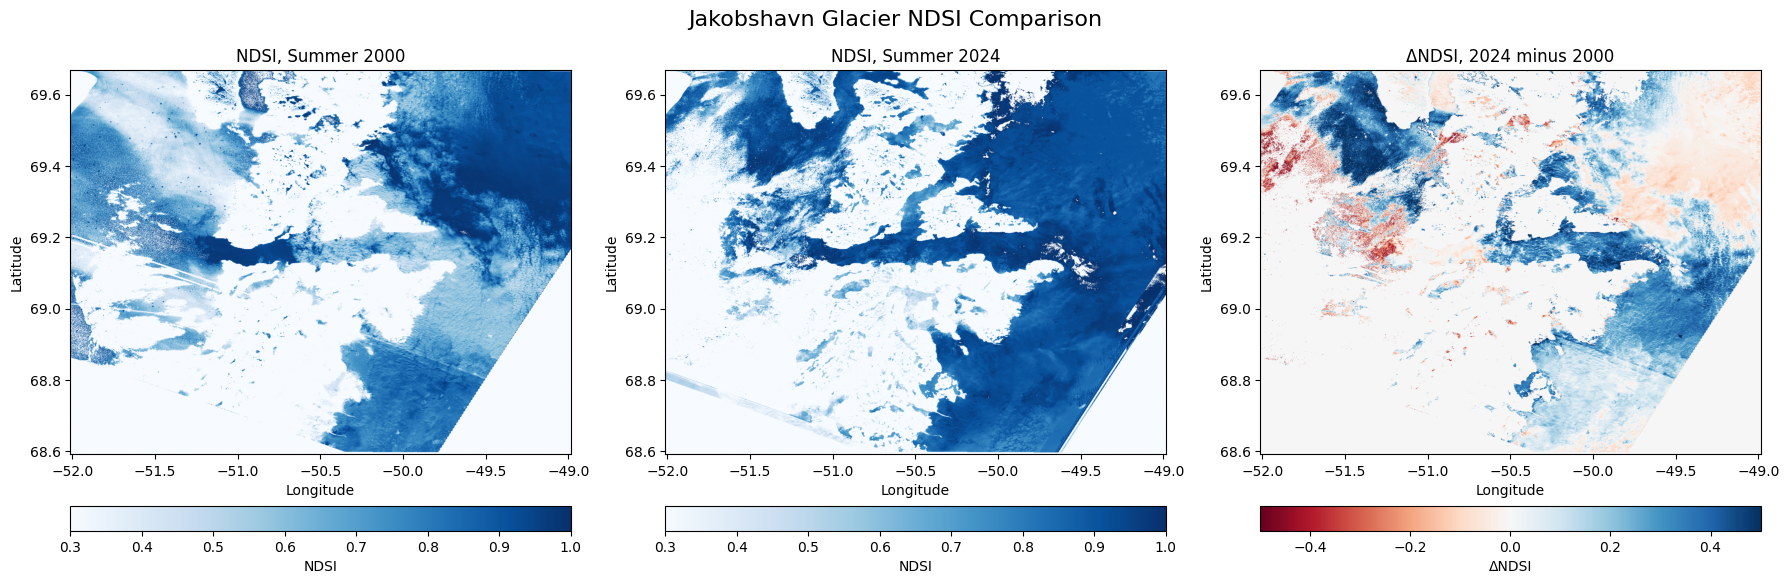

In [14]:
# Plotting and saving the images
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 2000 NDSI
img0 = axes[0].imshow(ndsi_2000_arr,
    extent=extent,
    origin="upper",
    cmap="Blues",
    vmin=0.3,
    vmax=1.0,
    aspect="auto")

axes[0].set_title("NDSI, Summer 2000")
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")
cbar0 = plt.colorbar(img0, ax=axes[0], orientation="horizontal", pad=0.1)
cbar0.set_label("NDSI")


# 2024 NDSI
img1 = axes[1].imshow(
    ndsi_2024_arr,
    extent=extent,
    origin="upper",
    cmap="Blues",
    vmin=0.3,
    vmax=1.0,
    aspect="auto")

axes[1].set_title("NDSI, Summer 2024")
axes[1].set_xlabel("Longitude")
axes[1].set_ylabel("Latitude")
cbar1 = plt.colorbar(img1, ax=axes[1], orientation="horizontal", pad=0.1)
cbar1.set_label("NDSI")


# dNDSI
img2 = axes[2].imshow(
    dndsi_arr,
    extent=extent,
    origin="upper",
    cmap="RdBu",
    vmin=-0.5,
    vmax=0.5,
    aspect="auto")

axes[2].set_title("ΔNDSI, 2024 minus 2000")
axes[2].set_xlabel("Longitude")
axes[2].set_ylabel("Latitude")
cbar2 = plt.colorbar(img2, ax=axes[2], orientation="horizontal", pad=0.1)
cbar2.set_label("ΔNDSI")


fig.suptitle("Jakobshavn Glacier NDSI Comparison", fontsize=16)
plt.tight_layout()
plt.savefig(directory/ "jakobshavn_ndsi_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

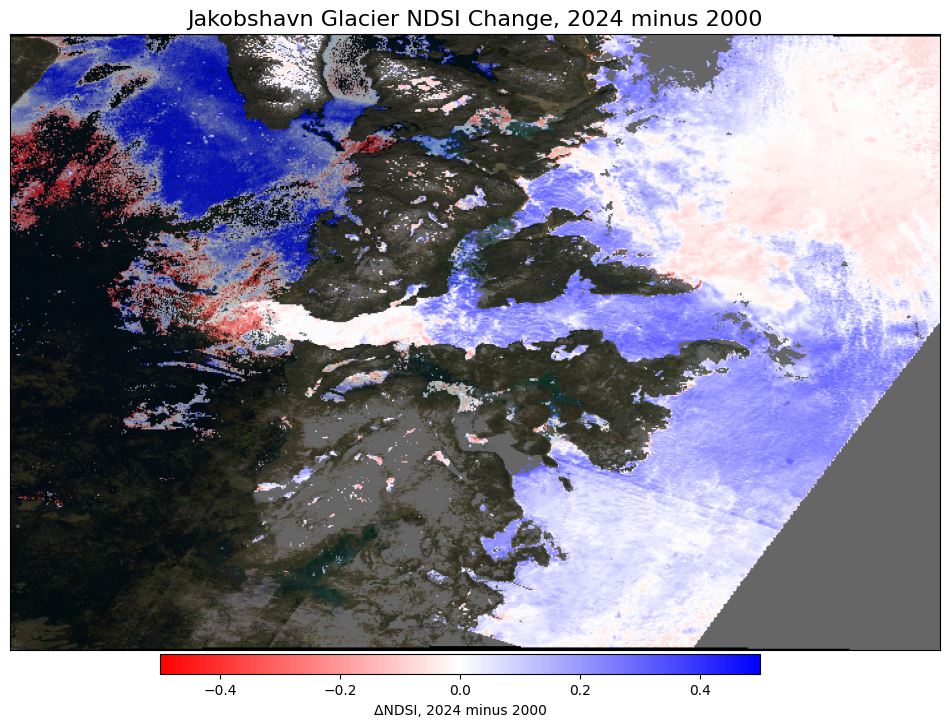

In [15]:
# Making a final dNDSI map overlaid on an optical image of the glacier
base_image = (
    l8.merge(l9)
    .filterBounds(AOI)
    .filterDate("2024-06-01", "2024-08-31")
    .median()
    .select(["SR_B4", "SR_B3", "SR_B2"])
    .multiply(0.0000275)
    .add(-0.2)
    .clip(AOI)
    .visualize(min=0, max=0.25, gamma=1.4))

overlay_image = ndsi_change.visualize(**dndsi_vis)


# Convert EE images to np arrays
base_arr = geemap.ee_to_numpy(base_image, region=AOI, scale=250)
overlay_arr = geemap.ee_to_numpy(overlay_image, region=AOI, scale=250)

fig_final, ax_final = plt.subplots(figsize=(12,8))

ax_final.imshow(base_arr, aspect="auto")
ax_final.imshow(overlay_arr, alpha=0.6, aspect="auto")
ax_final.set_xticks([])
ax_final.set_yticks([])
ax_final.set_title("Jakobshavn Glacier NDSI Change, 2024 minus 2000", fontsize=16)


# Add colour bar
cax = fig_final.add_axes([0.25, 0.08, 0.5, 0.025])

cmap = mcolors.LinearSegmentedColormap.from_list("dNDSI_cmap", dndsi_vis["palette"])
norm = mcolors.Normalize(vmin=dndsi_vis["min"], vmax=dndsi_vis["max"])

cbar = mcolorbar.ColorbarBase(
    cax,
    cmap=cmap,
    norm=norm,
    orientation="horizontal")

cbar.set_label("ΔNDSI, 2024 minus 2000")

plt.savefig(directory/ "jakobshavn_final_map.png", dpi=300, bbox_inches="tight")
plt.show()